<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/SP/PLANCK/planck_lamp_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Излучение АЧТ: фит спектра лампы накаливания формулой Планка

Спектрометр **AvaSpec-2048L** (ПЗС-линейка Sony ILX511). Два измерения одной лампы при разных режимах:

| Файл | Ток | Напряжение | τ_integ |
|---|---|---|---|
| `I3320mA_U3V.TXT` | 3.32 А | 3 В | 1.05 мс |
| `I2040mA_U1V.TXT` | 2.04 А | 1 В | 60.0 мс |

**План:**
1. Чтение `Sample` и `Dark`, вычитание тёмного тока.
2. Перевод длины волны в частоту, $I_\nu = I_\lambda \, \lambda^2/c$.
3. Коррекция на спектральную чувствительность матрицы $R(\lambda)$ (ILX511).
4. Фит формулой Планка по частоте: $$I(\nu) = A \, \nu^3 / (e^{h\nu/k_B T} - 1)$$.
5. Графики: исходный спектр, скорректированный спектр, фит Планка.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# Физические константы (СИ)
h  = 6.62607015e-34   # Дж·с
c  = 2.99792458e8     # м/с
kB = 1.380649e-23     # Дж/К

## 1. Чтение данных

Файл AvaSoft содержит шапку, затем строки `Wave;Sample;Dark;Reference;Scope`.
Пропускаем шапку и парсим только числовые строки. Заодно достаём время интегрирования.

In [5]:
def read_avaspec(fname):
    w, s, d = [], [], []
    integ = None
    with open(fname, 'r', encoding='latin-1') as f:
        for line in f:
            line = line.strip()
            if line.startswith('Integration time'):
                try:
                    integ = float(line.split(':')[1])
                except Exception:
                    pass
            if not line or ';' not in line:
                continue
            parts = [p.strip() for p in line.split(';')]
            try:
                w.append(float(parts[0]))
                s.append(float(parts[1]))
                d.append(float(parts[2]))
            except (ValueError, IndexError):
                continue
    return np.array(w), np.array(s), np.array(d), integ

f1 = 'I3320mA_U3V.TXT'
f2 = 'I2040mA_U1V.TXT'

w1, sample1, dark1, t1 = read_avaspec(f1)
w2, sample2, dark2, t2 = read_avaspec(f2)
assert np.allclose(w1, w2), 'Сетки длин волн не совпадают'
w   = w1                 # общая сетка, нм
lam = w * 1e-9           # м
nu  = c / lam            # Гц

print(f'Файл 1: 3.32 А · 3 В,  τ = {t1} мс,  {len(w1)} точек')
print(f'Файл 2: 2.04 А · 1 В,  τ = {t2} мс,  {len(w2)} точек')
print(f'Диапазон: {w.min():.1f} – {w.max():.1f} нм')

Файл 1: 3.32 А · 3 В,  τ = 1.05 мс,  1602 точек
Файл 2: 2.04 А · 1 В,  τ = 60.0 мс,  1602 точек
Диапазон: 173.9 – 1100.4 нм


## 2. Вычитание тёмного тока, перевод в частоту

Из `Sample` вычитаем `Dark` и нормируем на время интегрирования (counts/мс), чтобы можно было сравнивать абсолютные интенсивности двух файлов.

Якобиан перевода $\lambda \to \nu$: $\;I_\nu = I_\lambda \cdot |d\lambda/d\nu| = I_\lambda \cdot \lambda^2/c$.

In [6]:
I1_lam_raw = (sample1 - dark1) / t1   # counts/мс
I2_lam_raw = (sample2 - dark2) / t2

I1_nu_raw = I1_lam_raw * lam**2 / c
I2_nu_raw = I2_lam_raw * lam**2 / c

## 3. Спектральная чувствительность матрицы

AvaSpec-2048L использует ПЗС-линейку **Sony ILX511** (front-illuminated Si CCD, 2048 пикселей 14×200 мкм). Кривая «Spectral Sensitivity Characteristics (Typ.)» взята из datasheet Sony ILX511B (стр. 12). Точки оцифрованы вручную с графика и интерполируются монотонной сплайновой схемой PCHIP (без осцилляций).

Источник: <https://spectrecology.com/wp-content/uploads/2021/03/SONY-ILX511B.pdf>

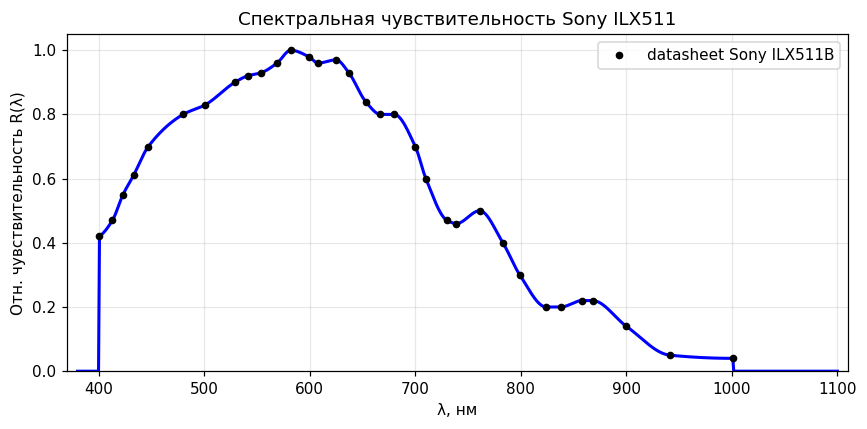

In [7]:
# Точки оцифрованы из графика Sony ILX511B
data = '''
# x	 y
400	0.42
413	0.47
423	0.55
433	0.61
447	0.70
480	0.80
501	0.83
529	0.90
541	0.92
554	0.93
569	0.96
582	1.00
599	0.98
608	0.96
625	0.97
637	0.93
653	0.84
667	0.80
680	0.80
700	0.70
710	0.60
730	0.47
739	0.46
761	0.50
783	0.40
799	0.30
824	0.20
838	0.20
858	0.22
868	0.22
900	0.14
941	0.05
1001	0.04
'''
ilx511_lam_nm,  ilx511_resp = np.genfromtxt(data.splitlines(),  unpack=True)
R_interp = PchipInterpolator(ilx511_lam_nm, ilx511_resp, extrapolate=False)

def R_lambda(lam_nm):
    # Относительная чувствительность спектрометра по λ (нм).
    r = R_interp(lam_nm)
    return np.where(np.isnan(r), 0.0, r)

# Покажем кривую
plt.figure(figsize=(8, 4))
lam_dense = np.linspace(380, 1100, 800)
plt.plot(lam_dense, R_lambda(lam_dense), 'b-', lw=2)
plt.plot(ilx511_lam_nm, ilx511_resp, 'ko', ms=4, label='datasheet Sony ILX511B')
plt.xlabel('λ, нм'); plt.ylabel('Отн. чувствительность R(λ)')
plt.title('Спектральная чувствительность Sony ILX511')
plt.grid(alpha=0.3); plt.legend()
plt.xlim(370, 1110); plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()

## 4. Коррекция на чувствительность

Делим измеренную интенсивность на $R(\lambda)$. На краях, где $R \to 0$, деление сильно усиливает шум — поэтому ставим порог $R > 0.05$ и за этим порогом считаем данные ненадёжными.

In [8]:
R = R_lambda(w)
R_safe = np.where(R > 0.05, R, np.nan)

I1_lam_corr = I1_lam_raw / R_safe
I2_lam_corr = I2_lam_raw / R_safe

I1_nu_corr = I1_lam_corr * lam**2 / c
I2_nu_corr = I2_lam_corr * lam**2 / c

## 5. Фит Планка по частоте

$$B_\nu(T) = \frac{2h\nu^3}{c^2}\,\frac{1}{e^{h\nu/k_B T} - 1}$$

Спектрометр некалиброван по абсолюту, поэтому в фит входит общий масштабный множитель $A$. Подгоняемая модель:

$$I(\nu) = A \cdot \frac{\nu^3}{e^{h\nu/k_B T} - 1}$$

Окно фита: 450–950 нм — там $R(\lambda) \gtrsim 0.2$, и данные надёжны.

In [9]:
def planck_nu(nu, A, T):
    x = h * nu / (kB * T)
    x = np.clip(x, 1e-6, 700)        # защита от переполнения
    return A * nu**3 / np.expm1(x)

def fit_planck(w, nu, I_nu_corr, lo_nm=450, hi_nm=950, T0=2700.0):
    m = (w >= lo_nm) & (w <= hi_nm) & np.isfinite(I_nu_corr) & (I_nu_corr > 0)
    i_pk = np.argmax(I_nu_corr[m])
    nu_pk = nu[m][i_pk]
    A0 = I_nu_corr[m][i_pk] * (np.exp(h*nu_pk/(kB*T0)) - 1) / nu_pk**3
    popt, pcov = curve_fit(planck_nu, nu[m], I_nu_corr[m],
                           p0=[A0, T0], maxfev=30000)
    yhat = planck_nu(nu[m], *popt)
    R2 = 1 - np.sum((I_nu_corr[m]-yhat)**2)/np.sum((I_nu_corr[m]-I_nu_corr[m].mean())**2)
    return popt, pcov, m, R2

LO, HI = 450, 950
popt1, pcov1, m1, R2_1 = fit_planck(w, nu, I1_nu_corr, LO, HI, T0=3000)
popt2, pcov2, m2, R2_2 = fit_planck(w, nu, I2_nu_corr, LO, HI, T0=2200)

T1, T2     = popt1[1], popt2[1]
T1_err     = np.sqrt(pcov1[1, 1])
T2_err     = np.sqrt(pcov2[1, 1])

print(f'Файл 1 (3.32 А · 3 В):  T = {T1:.0f} ± {T1_err:.0f} K   R² = {R2_1:.3f}')
print(f'Файл 2 (2.04 А · 1 В):  T = {T2:.0f} ± {T2_err:.0f} K   R² = {R2_2:.3f}')

Файл 1 (3.32 А · 3 В):  T = 2322 ± 27 K   R² = 0.896
Файл 2 (2.04 А · 1 В):  T = 1038 ± 12 K   R² = 0.949


## 6. Графики: исходный спектр, скорректированный, фит

На каждом графике три кривые:
- синяя — исходная $I_\lambda = $ Sample − Dark (нормированная на $\tau_\text{int}$);
- чёрная — после деления на $R(\lambda)$;
- красная — фит Планка (рисуется только в окне фита 450–950 нм).

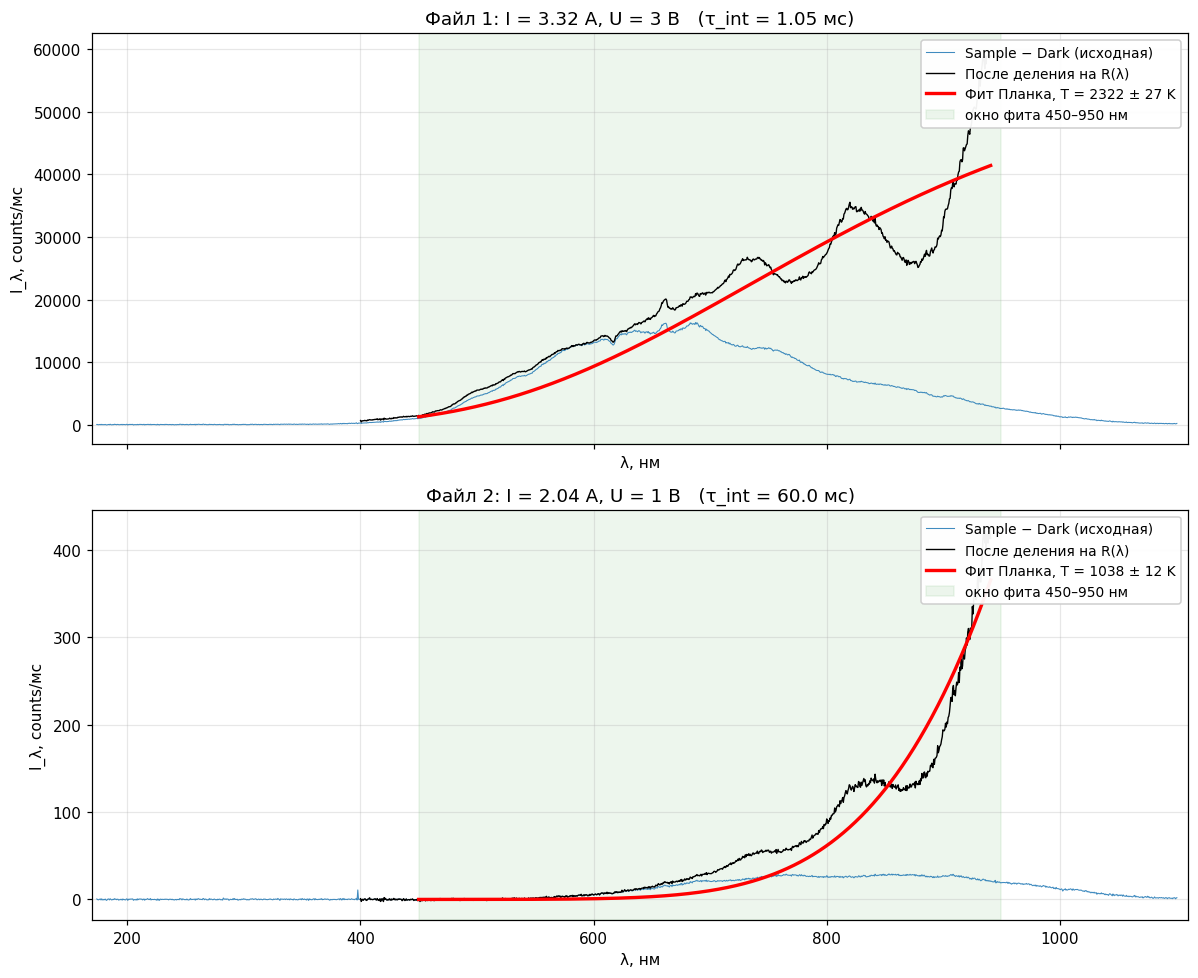

In [10]:
def planck_lam_model(lam_m, A, T):
    # Модель в шкале длин волн через перевод из ν.
    nu_local = c / lam_m
    return planck_nu(nu_local, A, T) * c / lam_m**2

I1_lam_model = planck_lam_model(lam, *popt1)
I2_lam_model = planck_lam_model(lam, *popt2)

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

datasets = [
    (axes[0], I1_lam_raw, I1_lam_corr, I1_lam_model, m1, T1, T1_err,
     f'Файл 1: I = 3.32 А, U = 3 В   (τ_int = {t1} мс)'),
    (axes[1], I2_lam_raw, I2_lam_corr, I2_lam_model, m2, T2, T2_err,
     f'Файл 2: I = 2.04 А, U = 1 В   (τ_int = {t2} мс)')
]
for ax, I_raw, I_corr, I_model, mfit, T, dT, title in datasets:
    ax.plot(w, I_raw, lw=0.7, color='C0', alpha=0.85,
            label='Sample − Dark (исходная)')
    valid = np.isfinite(I_corr)
    ax.plot(w[valid], I_corr[valid], lw=0.9, color='k',
            label='После деления на R(λ)')
    ax.plot(w[mfit], I_model[mfit], 'r-', lw=2.2,
            label=f'Фит Планка, T = {T:.0f} ± {dT:.0f} K')
    ax.axvspan(LO, HI, color='green', alpha=0.07,
               label=f'окно фита {LO}–{HI} нм')
    ax.set_xlim(170, 1110)
    ax.set_xlabel('λ, нм')
    ax.set_ylabel('I_λ, counts/мс')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95)

plt.tight_layout(); plt.show()

### То же в логарифмической шкале

В логарифме хорошо видно поведение в УФ и ИК — около 4 порядков по интенсивности.

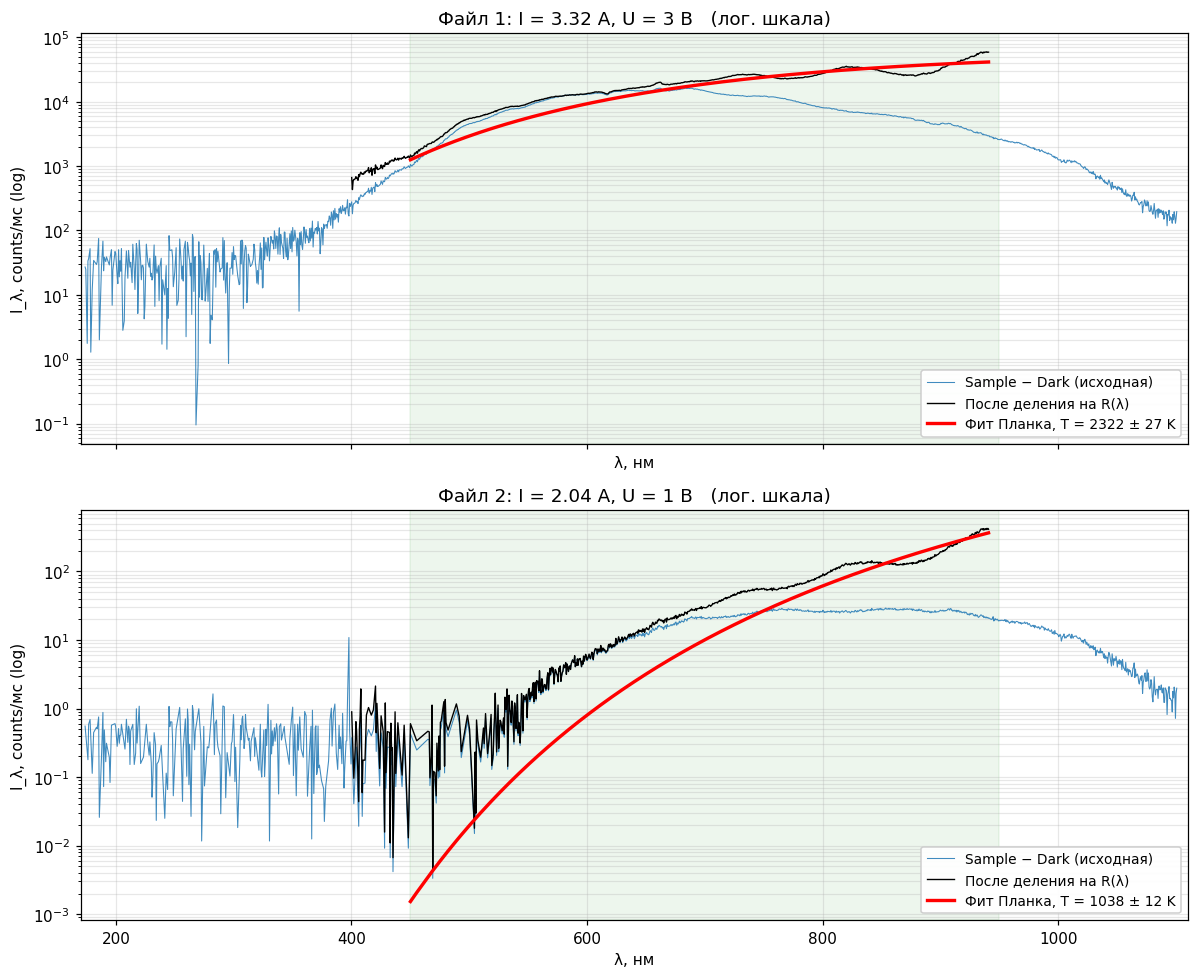

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

datasets = [
    (axes[0], I1_lam_raw, I1_lam_corr, I1_lam_model, m1, T1, T1_err,
     'Файл 1: I = 3.32 А, U = 3 В   (лог. шкала)'),
    (axes[1], I2_lam_raw, I2_lam_corr, I2_lam_model, m2, T2, T2_err,
     'Файл 2: I = 2.04 А, U = 1 В   (лог. шкала)')
]
for ax, I_raw, I_corr, I_model, mfit, T, dT, title in datasets:
    pos_raw = I_raw > 0
    ax.plot(w[pos_raw], I_raw[pos_raw], lw=0.7, color='C0', alpha=0.85,
            label='Sample − Dark (исходная)')
    valid = np.isfinite(I_corr) & (I_corr > 0)
    ax.plot(w[valid], I_corr[valid], lw=0.9, color='k',
            label='После деления на R(λ)')
    ax.plot(w[mfit], I_model[mfit], 'r-', lw=2.2,
            label=f'Фит Планка, T = {T:.0f} ± {dT:.0f} K')
    ax.axvspan(LO, HI, color='green', alpha=0.07)
    ax.set_yscale('log')
    ax.set_xlim(170, 1110)
    ax.set_xlabel('λ, нм')
    ax.set_ylabel('I_λ, counts/мс (log)')
    ax.set_title(title)
    ax.grid(alpha=0.3, which='both')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

plt.tight_layout(); plt.show()